In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.pipeline import make_pipeline
from sklearn.decomposition import TruncatedSVD
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from threadpoolctl import threadpool_limits
from sklearn.metrics import silhouette_score

## Data importing

In [48]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000038 entries, 0 to 10000037
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 305.2 MB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000019 entries, 0 to 5000018
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   userId   int64
 1   movieId  int64
dtypes: int64(2)
memory usage: 76.3 MB


## Collaborative-based

In [30]:
train.head()

,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


In [35]:
test.head()

,userId,movieId
0,1,2011
1,1,4144
2,1,5767
3,1,6711
4,1,7318


### We'll use a Sparse Matrix to avoid memory problems.

In [4]:
train_sparse_matrix = csr_matrix((train['rating'], (train['userId'], train['movieId'])))
train_sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10000038 stored elements and shape (162542, 209172)>

In [32]:
train_sparse_matrix.shape

(162542, 209172)

### Why TruncatedSVD?
#### Handling a user-item sparse matrix with millions of interactions requires excessive memory and can lead to RAM crashes. We applied `TruncatedSVD` (n_components=100) to compress the dimensionality. This engineering decision reduces memory footprint significantly while preserving the most critical latent features (user tastes) for accurate clustering.

In [5]:
svd = TruncatedSVD(n_components= 100, random_state=42)
train_svd_matrix = svd.fit_transform(train_sparse_matrix)
train_svd_matrix.shape

(162542, 100)

### Using Elbow method to determine the best clustering numberfor K-means

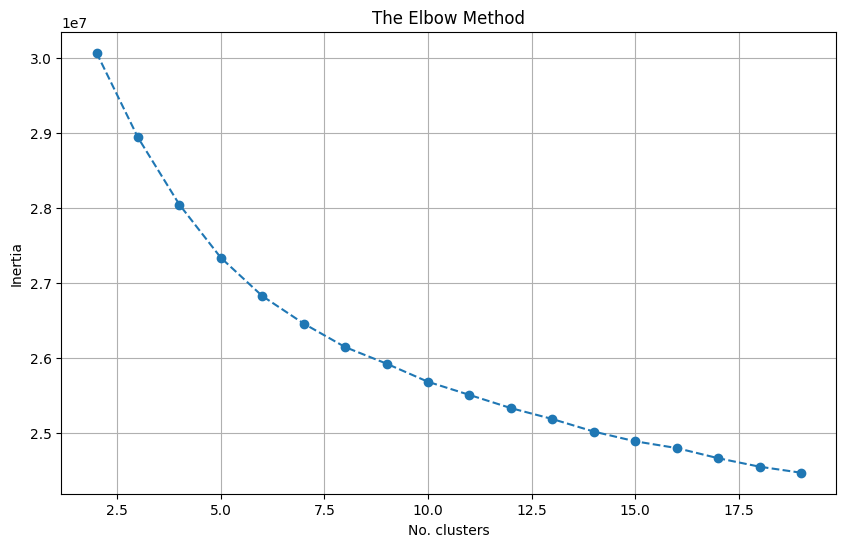

In [6]:
inertia_values = []
k_range = range(2, 20)

for k in k_range:
    kmeans = KMeans(n_clusters= k, random_state=42, n_init= 'auto')
    kmeans.fit(train_svd_matrix)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('No. clusters')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [12]:
optimal_value = 10

#Kmeans model
kmeans_model = KMeans(n_clusters= optimal_value, random_state= 42, n_init = 'auto')
kmeans_labels = kmeans_model.fit_predict(train_svd_matrix)

#GMM model
gmm_model = GaussianMixture(n_components= optimal_value, random_state= 42)
gmm_labels = gmm_model.fit_predict(train_svd_matrix)

sample_indices = np.random.choice(train_svd_matrix.shape[0], size=15000, replace=False)
svd_matrix_sample = train_svd_matrix[sample_indices]

hierarchical_model = AgglomerativeClustering(n_clusters=optimal_value)
hierarchical_labels = hierarchical_model.fit_predict(svd_matrix_sample)

In [17]:
kmeans_score = silhouette_score(train_svd_matrix, kmeans_labels, sample_size=100000, random_state= 42)
print(f"K-Means Silhouette Score: {kmeans_score:.4f}")

gmm_score = silhouette_score(train_svd_matrix, gmm_labels, sample_size=100000, random_state=42)
print(f"GMM Silhouette Score: {gmm_score:.4f}")

hirerachical_score = silhouette_score(svd_matrix_sample, hierarchical_labels, sample_size=100000, random_state=42)
print(f"Hirerachical Silhouette Score: {hirerachical_score:.4f}")

K-Means Silhouette Score: 0.0554
GMM Silhouette Score: -0.1184
Hirerachical Silhouette Score: 0.0227


#### K-means has the best score

### Visualize the model clusters using pca

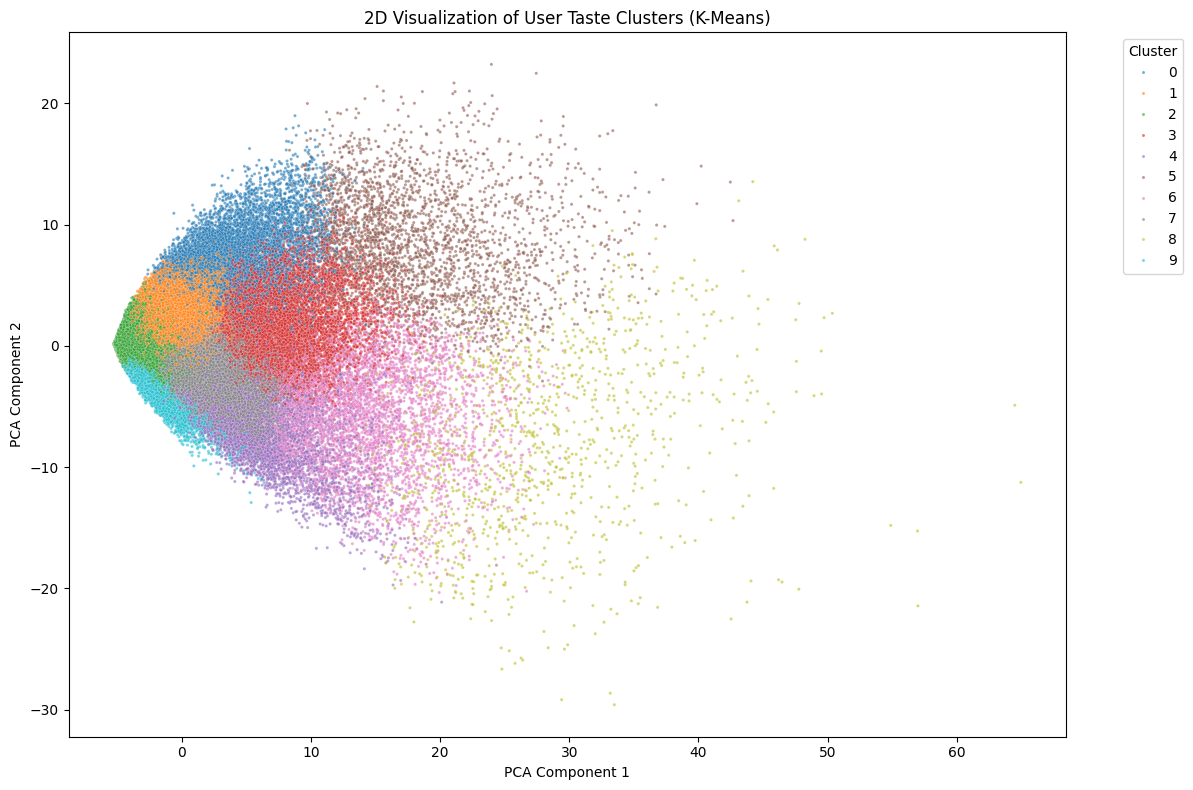

In [41]:
pca_2d = PCA(n_components=2, random_state=42)
matrix_2d = pca_2d.fit_transform(train_svd_matrix)

viz_df = pd.DataFrame({
    'X': matrix_2d[:, 0],
    'Y': matrix_2d[:, 1],
    'Cluster': kmeans_labels
})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='X', y='Y', hue='Cluster', palette='tab10', 
    data=viz_df, s=5, alpha=0.6
)
plt.title('2D Visualization of User Taste Clusters (K-Means)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Testing the K-means model on the test file

In [29]:
unique_users = train['userId'].unique()
unique_users = np.arange(kmeans_labels.shape[0])
user_clusters = pd.DataFrame({
    'userId': unique_users,
    'Cluster': kmeans_labels
})
user_clusters

,userId,Cluster
0,0,2
1,1,2
2,2,7
3,3,5
4,4,0
...,...,...
162537,162537,2
162538,162538,1
162539,162539,2
162540,162540,2


In [44]:
# 1. Map users to their clusters
unique_users = train['userId'].unique()
unique_users = np.arange(kmeans_labels.shape[0])
user_clusters = pd.DataFrame({'userId': unique_users, 'Cluster': kmeans_labels})

# 2. Merge train data with clusters to find "Tribal Averages"
train_with_clusters = train.merge(user_clusters, on='userId', how='left')
cluster_movie_avg = train_with_clusters.groupby(['Cluster', 'movieId'])['rating'].mean().reset_index()
cluster_movie_avg.rename(columns={'rating': 'predicted_rating'}, inplace=True)

# 3. Calculate Fallbacks (Global movie average & Overall average)
global_movie_avg = train.groupby('movieId')['rating'].mean().reset_index()
global_movie_avg.rename(columns={'rating': 'global_avg'}, inplace=True)
overall_avg = train['rating'].mean()

# 4. Predict on Test Data
predictions = test.merge(user_clusters, on='userId', how='left')
predictions = predictions.merge(cluster_movie_avg, on=['Cluster', 'movieId'], how='left')
predictions = predictions.merge(global_movie_avg, on='movieId', how='left')

# 5. Apply Fallbacks sequentially (Fill NaNs)
predictions['predicted_rating'] = predictions['predicted_rating'].fillna(predictions['global_avg'])
predictions['predicted_rating'] = predictions['predicted_rating'].fillna(overall_avg)

# 6. Format Submission File
predictions['Id'] = predictions['userId'].astype(str) + '_' + predictions['movieId'].astype(str)
predictions.rename(columns={'predicted_rating': 'rating'}, inplace=True)
submission = predictions[['Id', 'rating']]

# Save as compressed CSV
submission.to_csv('dude_final_submission.csv.gz', index=False, compression='gzip')
print("Submission successful")

Submission successful


In [45]:
submission

,Id,rating
0,1_2011,3.384425
1,1_4144,4.117241
2,1_5767,2.833333
3,1_6711,3.761875
4,1_7318,3.081967
...,...,...
5000014,162541_4079,3.272727
5000015,162541_4467,3.737705
5000016,162541_4980,3.156977
5000017,162541_5689,2.800000


In [46]:
train.head()

,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


In [47]:
sample_submission

,Id,rating
0,1_2011,1.0
1,1_4144,1.0
2,1_5767,1.0
3,1_6711,1.0
4,1_7318,1.0
...,...,...
5000014,162541_4079,1.0
5000015,162541_4467,1.0
5000016,162541_4980,1.0
5000017,162541_5689,1.0
